# Analyzing Software Engineering as a Lifecycle Process
- Modeling and concept mapping
- State extraction
- Utility experiment


## 1. Load DuckDB and build weekly counts


Dataset: Qlib
DuckDB: C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\data\raw\Qlib.duckdb
OCEL2: C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\data\raw\Qlib.sqlite
Closed event type id: 121


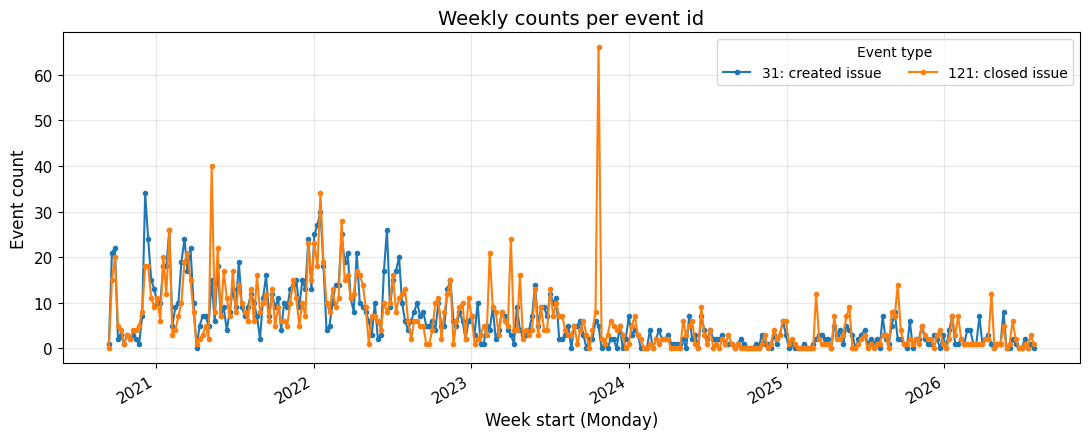

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\Qlib\weekly_open_closed_summary.csv


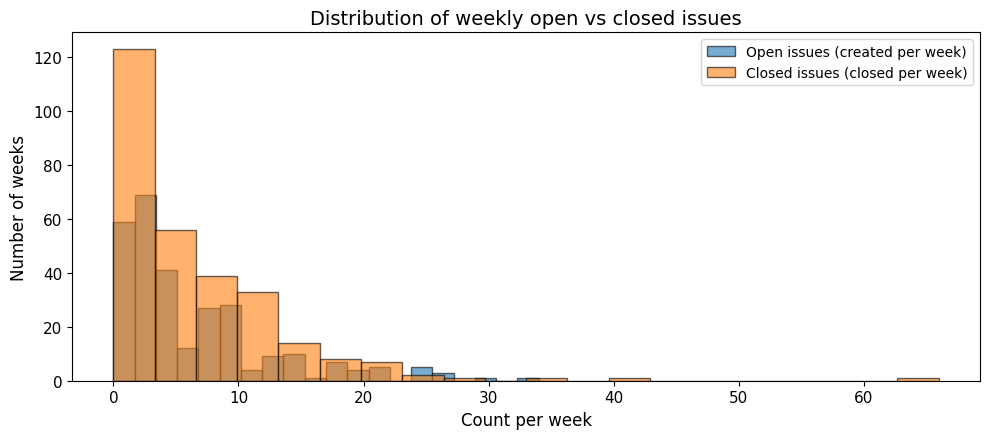

,Open issues (weekly created),Closed issues (weekly closed)
count,286.00,286.00
mean,6.36,6.52
std,6.36,7.12
min,0.00,0.00
25%,2.00,2.00
50%,4.00,4.50
75%,9.00,9.00
max,34.00,66.00


In [3]:
from pathlib import Path

from functions.configs import load_dataset_config
from functions.data_loading import (
    build_weekly_issue_counts,
    load_events_per_obj,
    load_objects_attributes,
)
from functions.plotting_anomaly import (
    plot_weekly_event_counts,
    plot_weekly_open_vs_closed_histogram,
    weekly_open_closed_summary_table,
)

# The only dataset-specific line in this notebook.
cfg = load_dataset_config("Qlib")

cfg.tables_dir.mkdir(parents=True, exist_ok=True)
cfg.figures_dir.mkdir(parents=True, exist_ok=True)

print("Dataset:", cfg.dataset_name)
print("DuckDB:", cfg.duckdb_path)
print("OCEL2:", cfg.sqlite_path)
print("Closed event type id:", cfg.closed_event_type_id)

eventsPerobj_df = load_events_per_obj(cfg)
objects_attributes = load_objects_attributes(cfg)
weekly = build_weekly_issue_counts(eventsPerobj_df, cfg)
plot_weekly_event_counts(weekly, cfg)
summary_table = weekly_open_closed_summary_table(weekly, cfg)
plot_weekly_open_vs_closed_histogram(weekly, cfg)
summary_table


## 2. Rolling IQR + lexicon state extraction


In [4]:
from functions.anomaly_pipeline import run_anomaly_state_extraction

weekly_closed_anomaly_frame, anomaly_context, anomaly_states, event_closed_title_join = (
    run_anomaly_state_extraction(weekly, eventsPerobj_df, objects_attributes, cfg)
)
anomaly_states.head()


Detected 19 rolling-IQR anomalies for event_type_id=121.
Joined title attribute rows: 1865 of 1865 event rows.
Saved anomaly states to C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\Qlib\anomaly_states.csv


,week_start,value,is_anomaly,anomaly_direction,anomaly_score,lower_bound,upper_bound,title_count,event_count,severity,component,reasoning,extraction_method,confidence,event_descriptions,titles_in_week
0,2020-12-07,18,True,high,2.583333,-1.750,10.250,17,18,P2,build & ci,Weekly closures show a clearly beyond-typical ...,rule_based,0.574792,"[closed (#112), closed (#108), closed (#15), c...",[尝试执行示例代码出错了ValueError: operands could not be ...
1,2020-12-14,18,True,high,0.500000,-4.500,15.500,18,18,P4,documentation,Weekly closures show a slightly beyond-typical...,rule_based,0.587714,"[closed (#139), closed (#119), closed (#122), ...","[Problem converting ""workflow_by_code.py"" to L..."
2,2021-02-01,26,True,high,0.014286,-9.125,25.875,25,26,P2,documentation,Weekly closures show a near-typical spike (26 ...,rule_based,0.672451,"[closed (#257), closed (#241), closed (#234), ...",[Add Qlib highfreq doc & Update DatatSet Init ...
3,2021-05-10,40,True,high,1.823529,-9.500,24.500,40,40,P4,documentation,Weekly closures show a clearly beyond-typical ...,rule_based,0.606389,"[closed (#139), closed (#102), closed (#229), ...","[Problem converting ""workflow_by_code.py"" to L..."
4,2021-12-20,23,True,high,0.076923,-3.500,22.500,22,23,P4,documentation,Weekly closures show a near-typical spike (23 ...,rule_based,0.649000,"[closed (#765), closed (#764), closed (#763), ...","[Improve normalization of volume, accelerate d..."


## 3. Export anomaly object / event IDs


In [5]:
from functions.anomaly_ids import export_anomaly_ids

anomaly_object_ids, anomaly_event_ids = export_anomaly_ids(anomaly_context, cfg)
anomaly_object_ids.head()



,week_start,object_id
0,2020-12-07,105899
1,2020-12-07,105934
2,2020-12-07,106046
3,2020-12-07,106069
4,2020-12-07,106152


## 4. Anomaly plots


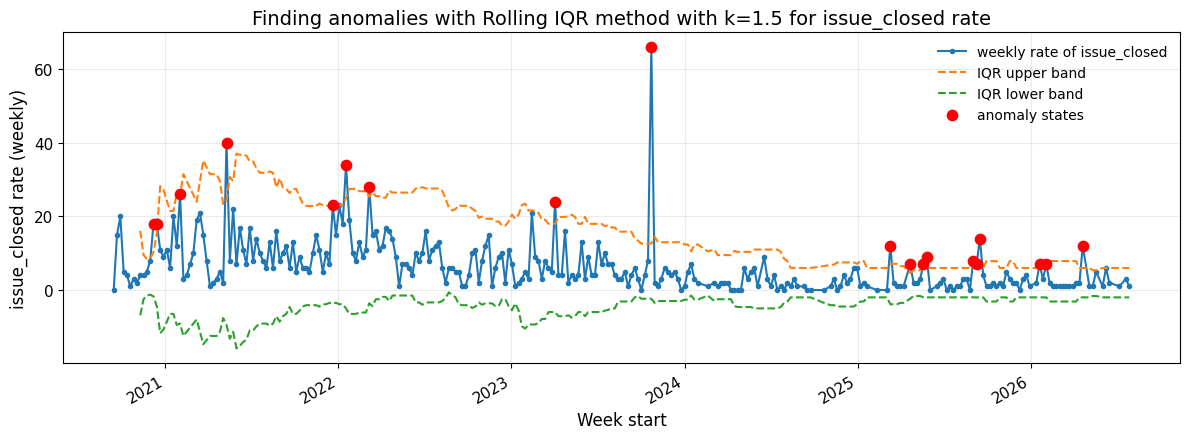

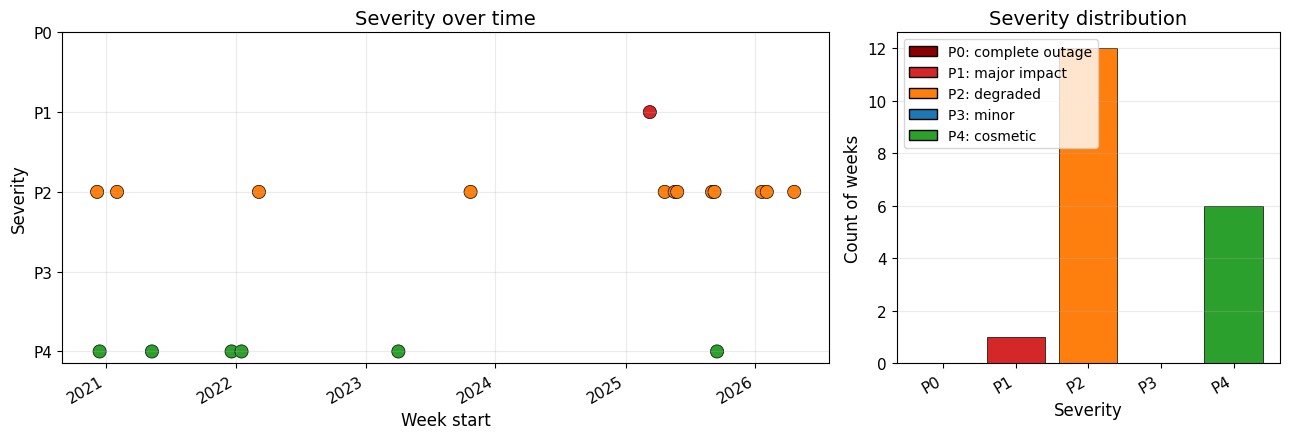

c:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\functions\plotting_anomaly.py:391: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.78, 1])


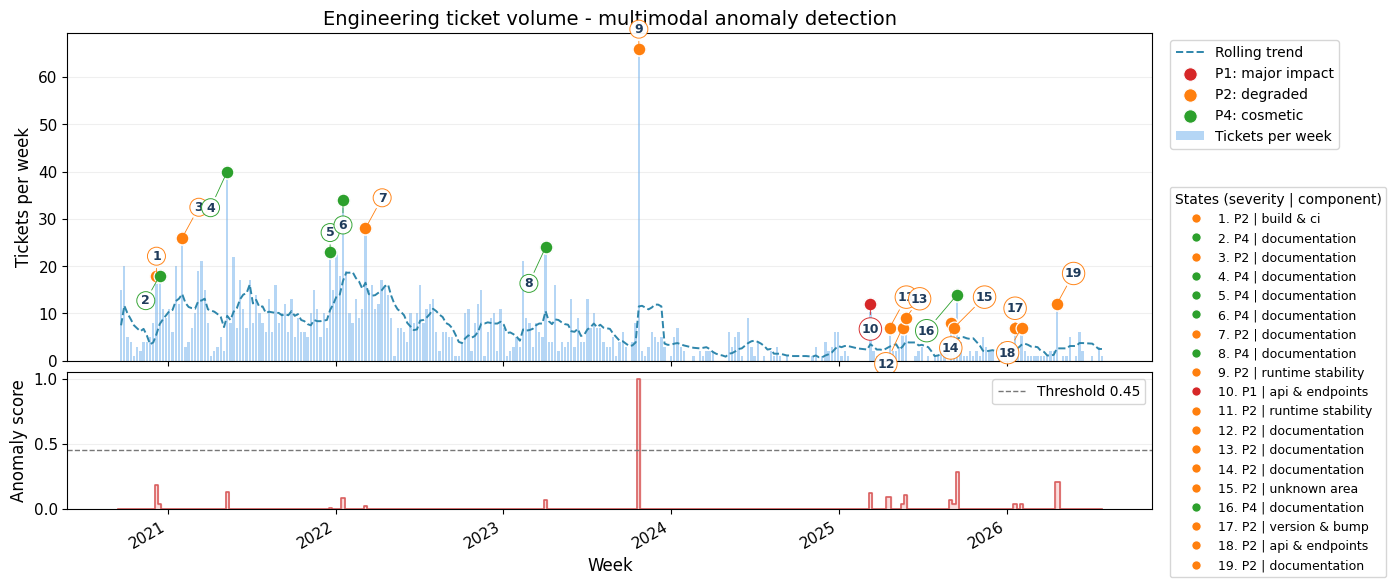

c:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\functions\plotting_anomaly.py:503: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.78, 0.985])


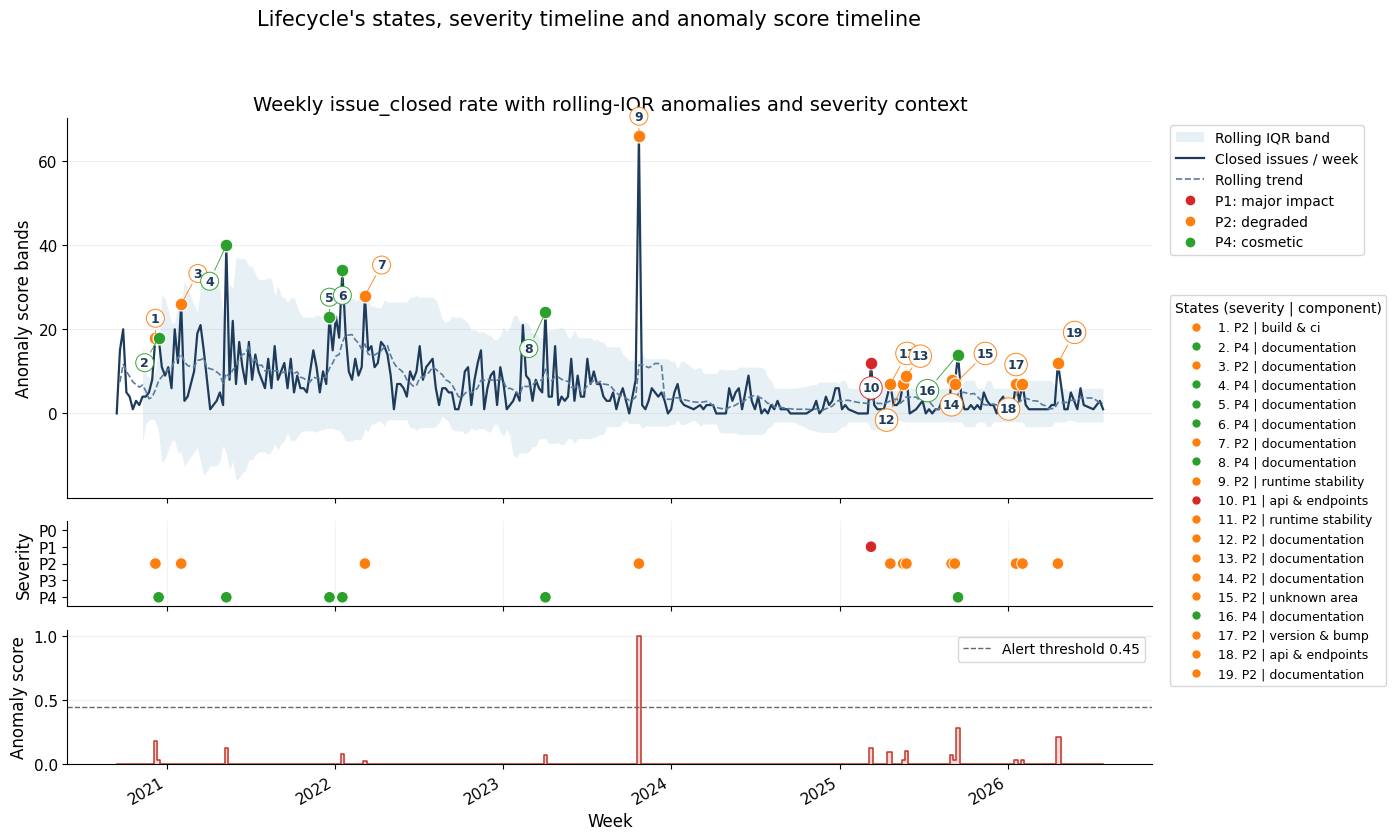

WindowsPath('C:/Users/mahsa.choopannezhadm/OneDrive - University of Liechtenstein/Desktop/PhD materials/codes/Lifecycles-Processes/results/figures/Qlib')

In [6]:
from functions.plotting_anomaly import plot_anomaly_figures

plot_anomaly_figures(weekly_closed_anomaly_frame, anomaly_states, cfg)


## 5. Commit context and type classification


commit_context summary: 19 rows x 17 columns
Saved commit_context to C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\Qlib\commit_context.csv
commit_typeclass_per_week summary: 19 rows x 33 columns

Mean category ratios across all anomaly weeks:
  feature_work  0.049
  bug_fixes     0.056
  tech_debt     0.017
  docs          0.005
  other         0.873

Mean category ratios by anomaly_direction:
  [high] feature_work=0.049  bug_fixes=0.056  tech_debt=0.017  docs=0.005  other=0.873

Saved commit_typeclass_per_week to C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\Qlib\commit_typeclass_per_week.csv


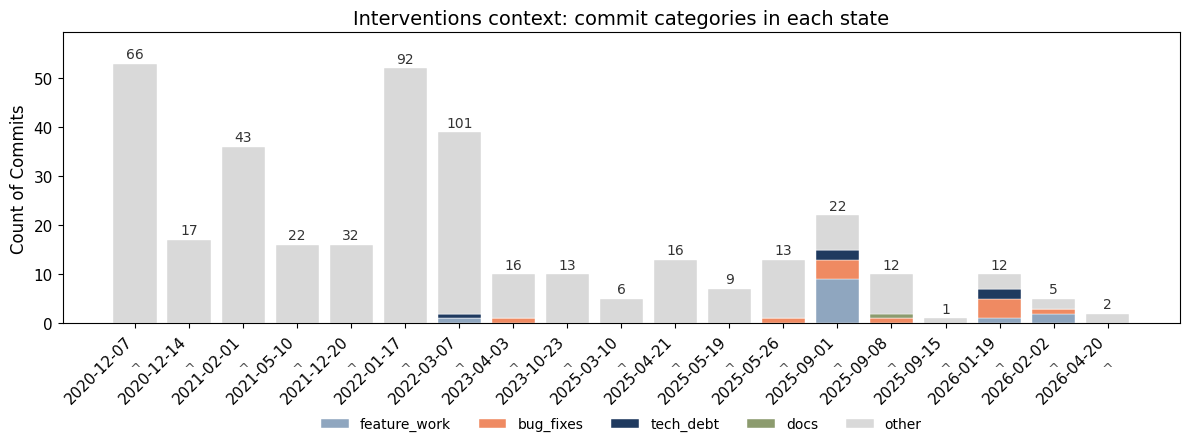

WindowsPath('C:/Users/mahsa.choopannezhadm/OneDrive - University of Liechtenstein/Desktop/PhD materials/codes/Lifecycles-Processes/results/figures/Qlib')

In [7]:
from functions.commits import build_commit_context, build_commit_typeclass
from functions.plotting_anomaly import plot_commit_category_stack

commit_context, event_commit_message_join = build_commit_context(
    weekly_closed_anomaly_frame, eventsPerobj_df, objects_attributes, cfg
)
commit_typeclass_per_week = build_commit_typeclass(commit_context, cfg)
plot_commit_category_stack(commit_context, commit_typeclass_per_week, cfg)


## 6. Flatten OCEL2 issue log


In [8]:
from functions.ocel_flatten import flatten_ocel2_issue_log

flat = flatten_ocel2_issue_log(cfg)


Flattened log: 22341 events, 1819 cases
  case:concept:name concept:name            time:timestamp
0            100019    committed 2021-02-01 16:37:36+00:00
1            100019      created 2021-02-01 16:37:47+00:00
2            100019       merged 2021-02-02 06:47:42+00:00
3            100019       closed 2021-02-02 06:47:42+00:00
4            100042    committed 2021-02-01 16:36:16+00:00
5            100042      created 2021-02-01 16:36:52+00:00
6            100042       merged 2021-02-02 06:34:58+00:00
7            100042       closed 2021-02-02 06:34:58+00:00
8            100042   referenced 2025-08-16 15:03:16+00:00
9            100068    committed 2021-02-01 16:33:31+00:00


## 7. Vitalizing subset from anomaly object IDs


In [9]:
from functions.ocel_flatten import build_vitalizing_subset

anomaly_events_df, anomaly_df = build_vitalizing_subset(flat, anomaly_object_ids)


Anomaly events df: 3835 rows, 364 cases


## 8. Preprocess + random control (MAX_REP / SEED unchanged)


In [10]:
from functions.preprocessing import build_preprocessed_logs

prep = build_preprocessed_logs(flat, anomaly_events_df, cfg)
flat_df_clean = prep["flat_df_clean"]
vitalizing_df_clean = prep["vitalizing_df_clean"]
random_case_control_df_clean = prep["random_case_control_df_clean"]
clean_log_groups_df = prep["clean_log_groups_df"]
all_cases_clean = prep["all_cases_clean"]
num_vital_cases_clean = prep["num_vital_cases_clean"]


=== Repetition cleaning summary (MAX_REP = 5) ===
Vitalizing: 124 -> 108 cases | 1024 -> 747 events
Whole: 549 -> 491 cases | 4728 -> 3373 events
Random control (rebuilt): 108 cases | 751 events


## 9. Discovery F1 evaluation on clean logs


In [11]:
from functions.discovery import evaluate_clean_logs

consolidated_results_table_clean, clean_log_groups_eventlog, miners = evaluate_clean_logs(
    clean_log_groups_df, cfg
)
consolidated_results_table_clean.head()


c:\Users\mahsa.choopannezhadm\anaconda3\envs\LCP\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
replaying log with TBR, completed traces :: 100%|██████████| 69/69 [00:00<00:00, 711.26it/s]

Expected records: 30 | Observed: 30

7) Consolidated results table in clean logs
               log_name         discovery_method  distinct_traces  \
0   random_case_control            alpha_classic               69   
1            vitalizing            alpha_classic               62   
2                 whole            alpha_classic              236   
3   random_case_control       heuristics_dep_0.6               69   
4            vitalizing       heuristics_dep_0.6               62   
5                 whole       heuristics_dep_0.6              236   
6   random_case_control       heuristics_dep_0.7               69   
7            vitalizing       heuristics_dep_0.7               62   
8                 whole       heuristics_dep_0.7              236   
9   random_case_control       heuristics_dep_0.8               69   
10           vitalizing       heuristics_dep_0.8               62   
11                whole       heuristics_dep_0.8              236   
12  random_case_contro

,log_name,discovery_method,distinct_traces,generalization,fitness,precision,f_score,size,cfc,simplicity,status,error
0,random_case_control,alpha_classic,69,0.571585,0.601843,0.222020,0.324377,94.0,14.0,0.480519,ok,None
1,vitalizing,alpha_classic,62,0.575778,0.552724,0.250179,0.344450,78.0,14.0,0.578947,ok,None
2,whole,alpha_classic,236,0.625366,0.533801,0.213661,0.305172,128.0,39.0,0.408696,ok,None
3,random_case_control,heuristics_dep_0.6,69,0.409654,0.858695,0.698034,0.770074,354.0,19.0,0.477663,ok,None
4,vitalizing,heuristics_dep_0.6,62,0.447359,0.817621,0.664549,0.733181,280.0,10.0,0.511312,ok,None


## 10. Utility figures


Plotting from 30 successful rows
Miner configs: ['alpha_classic', 'heuristics_dep_0.6', 'heuristics_dep_0.7', 'heuristics_dep_0.8', 'heuristics_dep_0.9', 'inductive_IM', 'inductive_IMf_noise_0.3', 'inductive_IMf_noise_0.4', 'inductive_IMf_noise_0.5', 'inductive_IMf_noise_0.6']
Log groups: ['random_case_control', 'vitalizing', 'whole']
Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\figures\Qlib\clean_log_f_score_grouped_bars.{png,pdf}


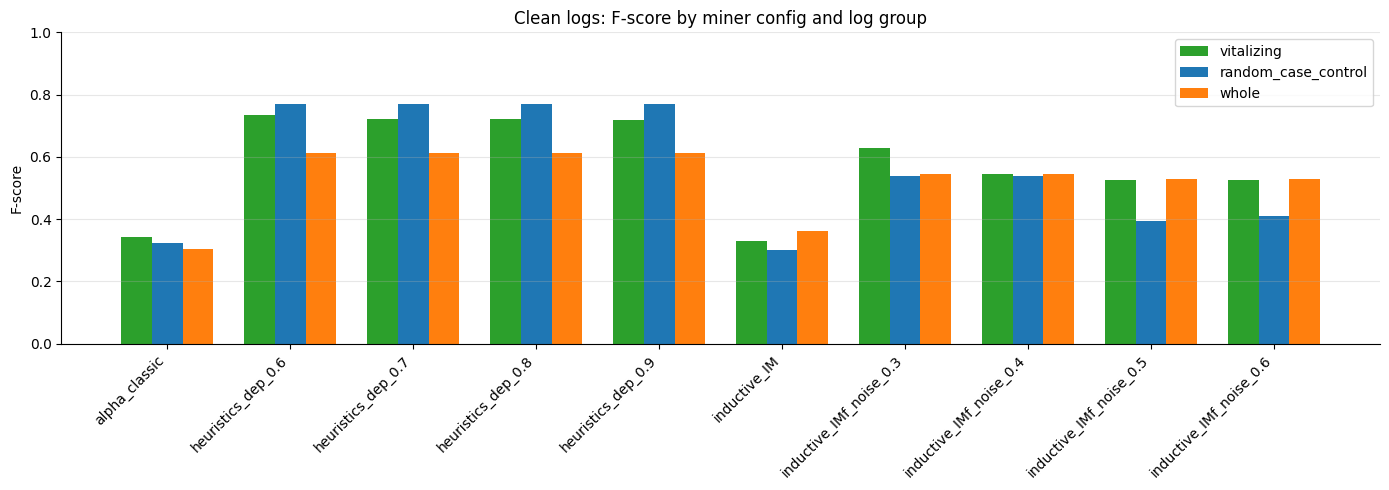

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\figures\Qlib\clean_log_fitness_precision.{png,pdf}


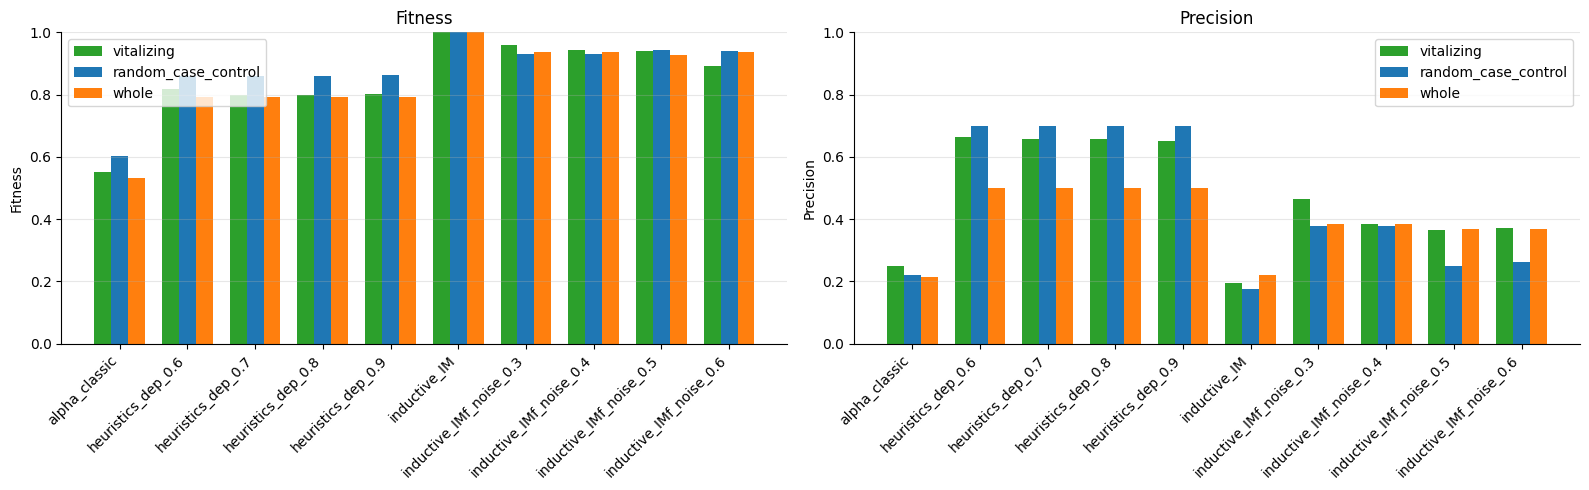

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\figures\Qlib\clean_log_complexity.{png,pdf}


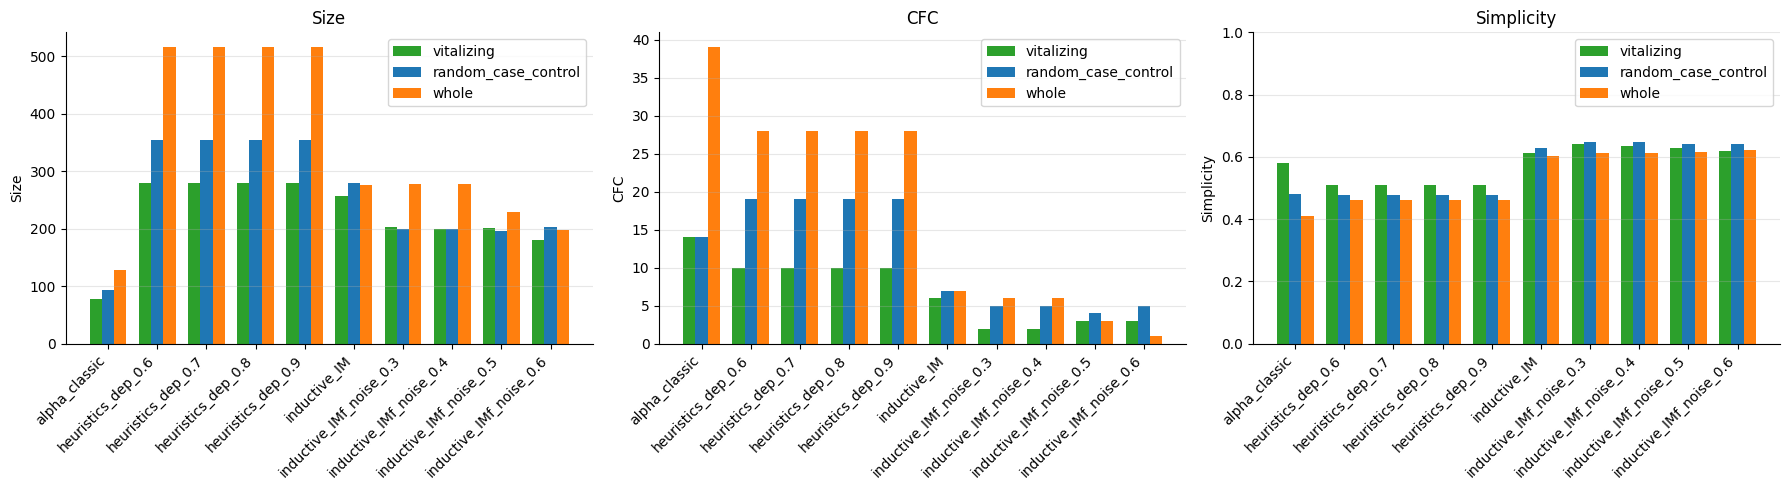

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\figures\Qlib\clean_log_threshold_sensitivity.{png,pdf}


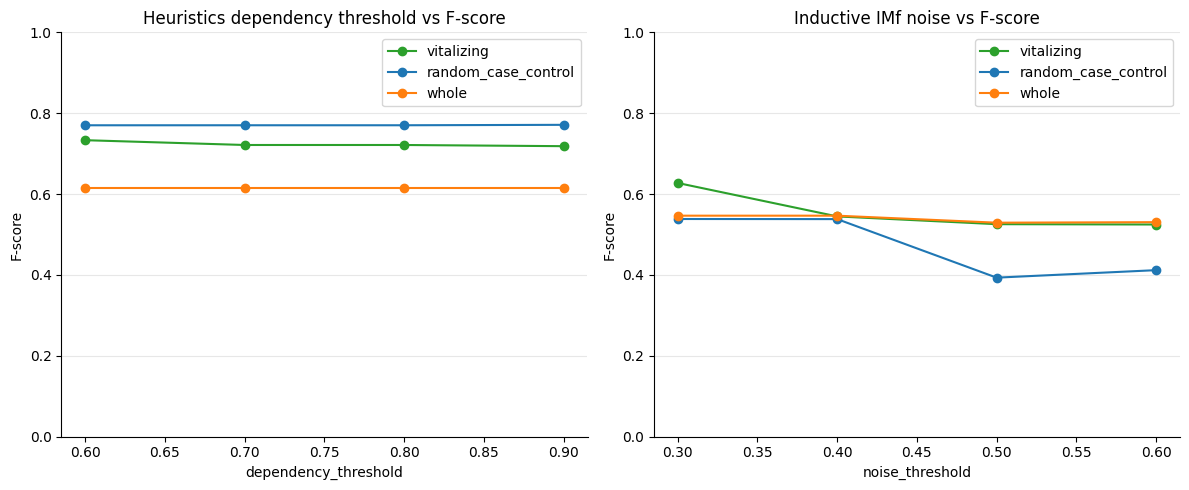

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\figures\Qlib\clean_log_f_score_slopegraph.{png,pdf}


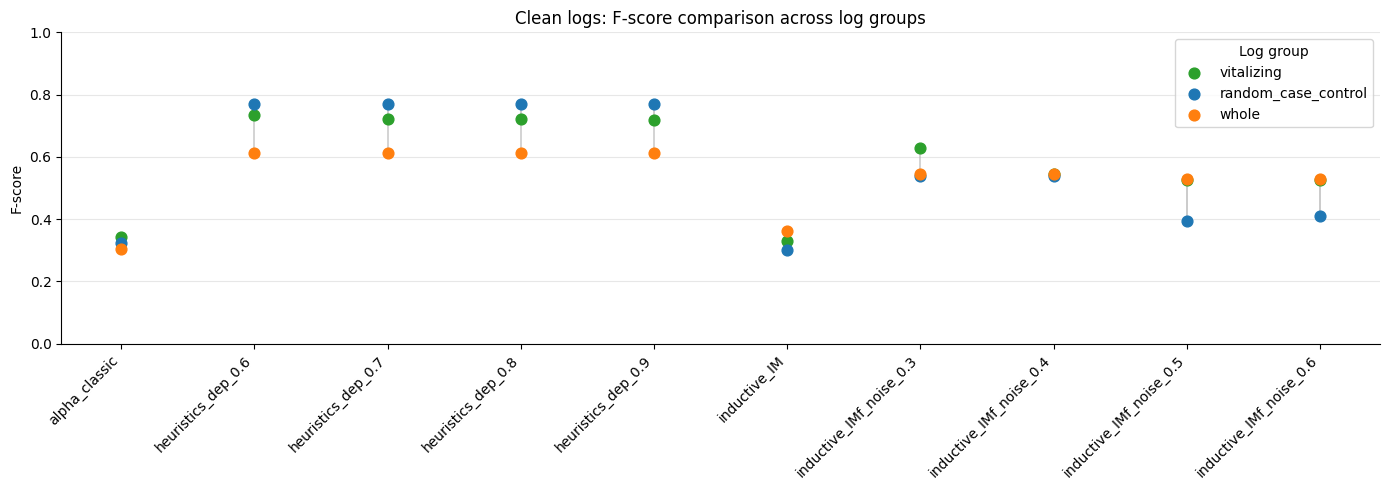

{'wide_f_score_clean': discovery_method     alpha_classic  heuristics_dep_0.6  heuristics_dep_0.7  \
 log_name                                                                     
 random_case_control       0.324377            0.770074            0.770127   
 vitalizing                0.344450            0.733181            0.721319   
 whole                     0.305172            0.614017            0.614017   
 
 discovery_method     heuristics_dep_0.8  heuristics_dep_0.9  inductive_IM  \
 log_name                                                                    
 random_case_control            0.770127            0.771185      0.300949   
 vitalizing                     0.721319            0.718377      0.328634   
 whole                          0.614017            0.614017      0.362945   
 
 discovery_method     inductive_IMf_noise_0.3  inductive_IMf_noise_0.4  \
 log_name                                                                
 random_case_control                 0.53

In [12]:
from functions.plotting_utility import plot_utility_figures

plot_utility_figures(consolidated_results_table_clean, cfg)


## 11. Seed reproducibility


replaying log with TBR, completed traces :: 100%|██████████| 77/77 [00:00<00:00, 945.10it/s]


Reproducibility over 10 seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Discovery metrics summary (mean/std/CV per miner):
          discovery_method  fitness_mean  fitness_std  fitness_cv  \
0            alpha_classic      0.598943     0.089361    0.149197   
1       heuristics_dep_0.6      0.817415     0.027043    0.033083   
2       heuristics_dep_0.7      0.817102     0.026424    0.032339   
3       heuristics_dep_0.8      0.817582     0.026555    0.032480   
4       heuristics_dep_0.9      0.816341     0.026335    0.032260   
5             inductive_IM      1.000000     0.000000    0.000000   
6  inductive_IMf_noise_0.3      0.936149     0.008322    0.008889   
7  inductive_IMf_noise_0.4      0.936248     0.009408    0.010049   
8  inductive_IMf_noise_0.5      0.933484     0.019482    0.020870   
9  inductive_IMf_noise_0.6      0.916521     0.064031    0.069863   

   precision_mean  precision_std  precision_cv  f_score_mean  f_score_std  \
0        0.231895       0.036186      0.156045   

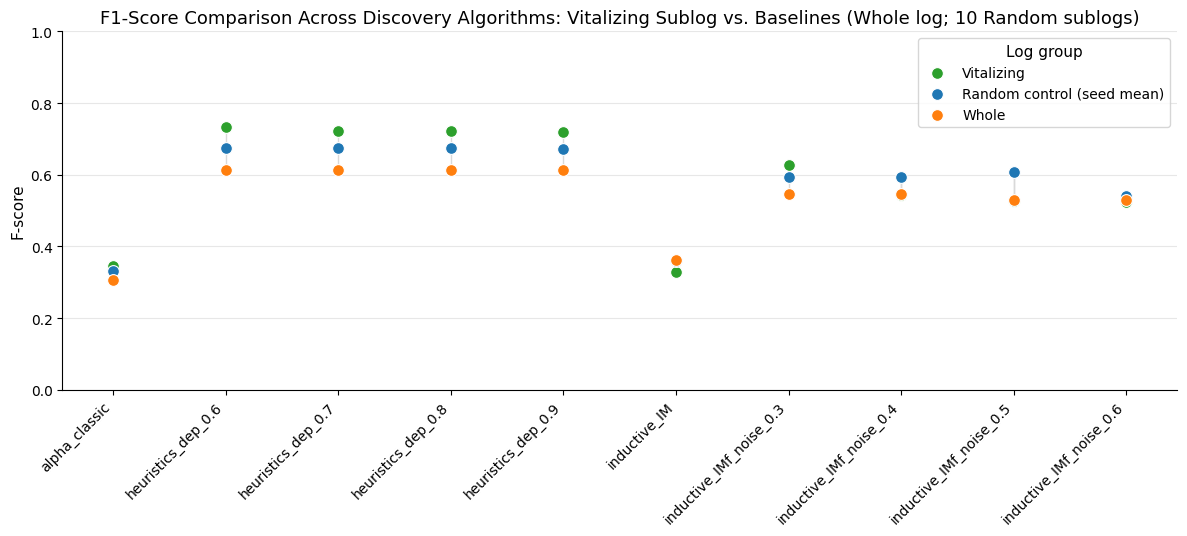

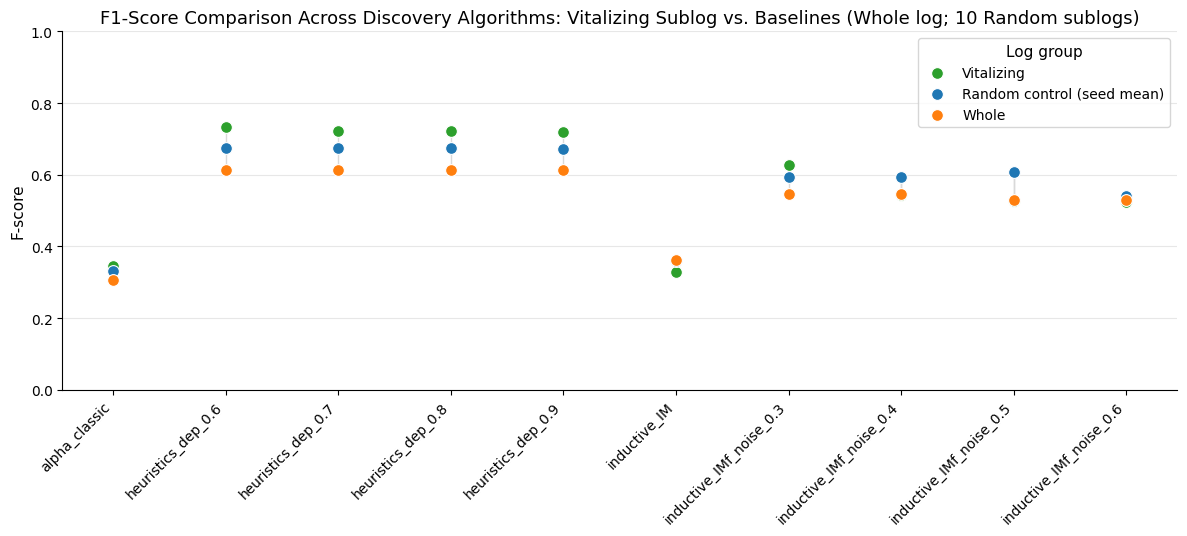

In [13]:
from functions.plotting_utility import plot_repro_slopegraph
from functions.reproducibility import run_seed_reproducibility

repro = run_seed_reproducibility(
    flat_df_clean=flat_df_clean,
    all_cases_clean=all_cases_clean,
    num_vital_cases_clean=num_vital_cases_clean,
    miners=miners,
    consolidated_results_table_clean=consolidated_results_table_clean,
    cfg=cfg,
)
consolidated_results_table_clean_repro = repro["consolidated_results_table_clean_repro"]
plot_repro_slopegraph(consolidated_results_table_clean_repro, cfg)


## 12. Log complexity metrics (process-complexity / EPA)


In [ ]:
from functions.complexity_metrics import compute_log_complexity_table

log_complexity_similarity_table = compute_log_complexity_table(clean_log_groups_eventlog, cfg)
log_complexity_similarity_table
